# Visual Anomaly Detection - trening end-to-end

## 1. Konfiguracja

In [3]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data_generator.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_DIR = PROJECT_ROOT / "dataset"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
NUMERICAL_MODEL_PATH = ARTIFACTS_DIR / "numerical_baseline.pkl"
VISUAL_MODEL_PATH = ARTIFACTS_DIR / "visual_detector.pt"

RANDOM_STATE = 42
N_SERIES = 300
SERIES_LENGTH = 512
WINDOW_SIZE = 100
STRIDE = 20
VISUAL_EPOCHS = 12
VISUAL_BATCH_SIZE = 32
VISUAL_IMAGE_SIZE = 224

TRAIN_RATIO = 0.7
VAL_RATIO = 0.15

windows_per_series = ((SERIES_LENGTH - WINDOW_SIZE) // STRIDE) + 1
n_train = int(round(N_SERIES * TRAIN_RATIO))
n_val = int(round(N_SERIES * VAL_RATIO))
n_test = N_SERIES - n_train - n_val
min_split_series = min(n_train, n_val, n_test)
theoretical_max_per_class = (min_split_series * windows_per_series) // 2

TARGET_WINDOWS_PER_CLASS_PER_SPLIT = min(350, theoretical_max_per_class)

HAS_SKLEARN = importlib.util.find_spec("sklearn") is not None
HAS_TORCH = importlib.util.find_spec("torch") is not None

if HAS_TORCH:
    import torch
    HAS_CUDA = torch.cuda.is_available()
else:
    HAS_CUDA = False

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset dir: {DATASET_DIR}")
print(f"Artifacts dir: {ARTIFACTS_DIR}")
print(f"scikit-learn available: {HAS_SKLEARN}")
print(f"PyTorch available: {HAS_TORCH}")
print(f"CUDA available: {HAS_CUDA}")
print(f"Windows per series: {windows_per_series}")
print(f"Split series counts -> train: {n_train}, val: {n_val}, test: {n_test}")
print(f"Theoretical max windows/class/split: {theoretical_max_per_class}")
print(f"Requested windows/class/split: {TARGET_WINDOWS_PER_CLASS_PER_SPLIT}")
print("If balancing still fails, notebook falls back to automatic balancing.")

Project root: c:\Users\PC\Desktop\anomalie
Dataset dir: c:\Users\PC\Desktop\anomalie\dataset
Artifacts dir: c:\Users\PC\Desktop\anomalie\artifacts
scikit-learn available: True
PyTorch available: True
CUDA available: True
Windows per series: 21
Split series counts -> train: 210, val: 45, test: 45
Theoretical max windows/class/split: 472
Requested windows/class/split: 350
If balancing still fails, notebook falls back to automatic balancing.


## 2. Generowanie danych i obrazow wykresow

In [4]:
from data_generator import GeneratorConfig, build_dataset

generator_config = GeneratorConfig(
    output_dir=DATASET_DIR,
    n_series=N_SERIES,
    series_length=SERIES_LENGTH,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    anomaly_series_fraction=0.7,
    windows_per_class_per_split=TARGET_WINDOWS_PER_CLASS_PER_SPLIT,
    random_state=RANDOM_STATE,
    plot_backend="auto",
    overwrite=True,
)

try:
    numeric_df, metadata_df = build_dataset(generator_config)
except ValueError as exc:
    if "Cannot sample" not in str(exc):
        raise
    print("Requested windows/class/split is too high for this random draw.")
    print("Falling back to automatic per-split balancing (min available class count).")
    fallback_config = GeneratorConfig(
        output_dir=DATASET_DIR,
        n_series=N_SERIES,
        series_length=SERIES_LENGTH,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
        train_ratio=TRAIN_RATIO,
        val_ratio=VAL_RATIO,
        anomaly_series_fraction=0.7,
        windows_per_class_per_split=None,
        random_state=RANDOM_STATE,
        plot_backend="auto",
        overwrite=True,
    )
    numeric_df, metadata_df = build_dataset(fallback_config)

print(f"Time points: {len(numeric_df):,}")
print(f"Chart windows: {len(metadata_df):,}")
display(metadata_df.groupby(["split", "label_name"]).size().unstack(fill_value=0))

Requested windows/class/split is too high for this random draw.
Falling back to automatic per-split balancing (min available class count).
Time points: 153,600
Chart windows: 4,062


label_name,anomaly,normal
split,,
test,310,310
train,1395,1395
val,326,326


## 3. Podglad przykladowych wykresow

test / normal / anomalies in window: 0


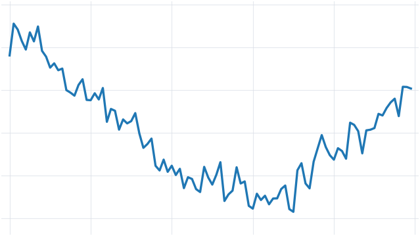

test / normal / anomalies in window: 0


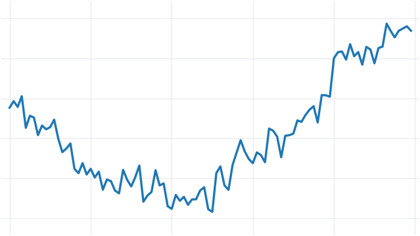

test / normal / anomalies in window: 0


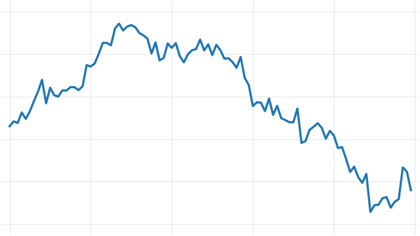

test / anomaly / anomalies in window: 50


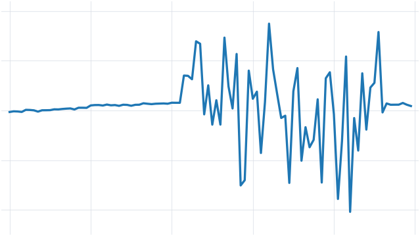

test / anomaly / anomalies in window: 52


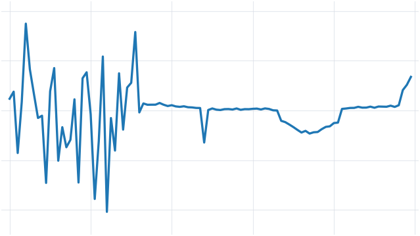

test / anomaly / anomalies in window: 23


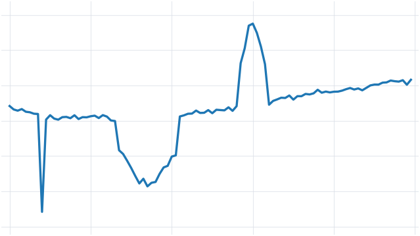

In [5]:
from IPython.display import display
from PIL import Image

sample_rows = metadata_df.groupby("label_name", group_keys=False).head(3)
for row in sample_rows.itertuples(index=False):
    print(f"{row.split} / {row.label_name} / anomalies in window: {row.anomaly_count}")
    image = Image.open(DATASET_DIR / row.image_path).convert("RGB")
    image.thumbnail((420, 240))
    display(image)

## 4. Trening baseline numerycznego

In [6]:
from numerical_baseline import NumericalAnomalyBaseline, load_window_dataset
from evaluation import binary_metrics

features, y_all, all_meta = load_window_dataset(DATASET_DIR)
train_mask = all_meta["split"].eq("train").to_numpy()
test_mask = all_meta["split"].eq("test").to_numpy()

numerical_model_type = "random_forest" if HAS_SKLEARN else "robust_threshold"
numerical_model = NumericalAnomalyBaseline(
    model_type=numerical_model_type,
    random_state=RANDOM_STATE,
)
numerical_model.fit(features.loc[train_mask], y_all[train_mask])
numerical_model.save(NUMERICAL_MODEL_PATH)

y_num = y_all[test_mask]
num_score = numerical_model.predict_proba(features.loc[test_mask])
num_meta = all_meta.loc[test_mask].reset_index(drop=True)
num_metrics = binary_metrics(y_num, num_score)

print(f"Numerical model: {numerical_model_type}")
print(f"Saved to: {NUMERICAL_MODEL_PATH}")
display(num_metrics)

Numerical model: random_forest
Saved to: c:\Users\PC\Desktop\anomalie\artifacts\numerical_baseline.pkl


{'accuracy': 0.9983870967741936,
 'precision': 1.0,
 'recall': 0.9967741935483871,
 'f1_score': 0.9983844911147012,
 'roc_auc': 0.9999687825182102}

## 5. Trening modelu wizualnego CNN na GPU (CUDA)


In [7]:
if HAS_TORCH and HAS_CUDA:
    from visual_anomaly_detector import VisualTrainingConfig, train_visual_detector

    visual_config = VisualTrainingConfig(
        image_size=VISUAL_IMAGE_SIZE,
        batch_size=VISUAL_BATCH_SIZE,
        epochs=VISUAL_EPOCHS,
        learning_rate=1e-3,
        device="cuda",
        random_state=RANDOM_STATE,
    )
    visual_detector = train_visual_detector(
        dataset_dir=DATASET_DIR,
        model_out=VISUAL_MODEL_PATH,
        config=visual_config,
    )
    y_vis, vis_score, vis_meta = visual_detector.predict_dataset_split(DATASET_DIR, split="test")
    vis_metrics = binary_metrics(y_vis, vis_score)
    print("Visual model trained on device: cuda")
    print(f"Saved to: {VISUAL_MODEL_PATH}")
    display(vis_metrics)
elif HAS_TORCH and not HAS_CUDA:
    y_vis, vis_score, vis_meta, vis_metrics = None, None, None, None
    raise RuntimeError(
        "PyTorch is installed, but CUDA is not available. "
        "Install CUDA-enabled PyTorch or update NVIDIA drivers, then rerun."
    )
else:
    y_vis, vis_score, vis_meta, vis_metrics = None, None, None, None
    print("PyTorch is not installed, so visual CNN training was skipped.")
    print("Install project dependencies first, for example:")
    print("python -m pip install -r requirements.txt")

Visual model trained on device: cuda
Saved to: c:\Users\PC\Desktop\anomalie\artifacts\visual_detector.pt


{'accuracy': 0.9951612903225806,
 'precision': 0.9904153354632588,
 'recall': 1.0,
 'f1_score': 0.9951845906902087,
 'roc_auc': 1.0}

## 6. Porownanie metod i przypadki rozbieznosci

In [8]:
from evaluation import build_report, save_case_sheets

if HAS_TORCH and HAS_CUDA:
    report_df, comparison_df = build_report(
        numerical_result=(y_num, num_score, num_meta),
        visual_result=(y_vis, vis_score, vis_meta),
    )
    report_path = ARTIFACTS_DIR / "evaluation_report.csv"
    comparison_path = ARTIFACTS_DIR / "prediction_comparison.csv"
    report_df.to_csv(report_path, index=False)
    comparison_df.to_csv(comparison_path, index=False)
    save_case_sheets(DATASET_DIR, comparison_df, ARTIFACTS_DIR, max_cases=9)

    print(f"Report saved to: {report_path}")
    print(f"Comparison saved to: {comparison_path}")
    display(report_df)
else:
    print("Full comparison needs the visual model trained on CUDA. Install CUDA-enabled PyTorch and rerun.")

Report saved to: c:\Users\PC\Desktop\anomalie\artifacts\evaluation_report.csv
Comparison saved to: c:\Users\PC\Desktop\anomalie\artifacts\prediction_comparison.csv


,method,accuracy,precision,recall,f1_score,roc_auc
0,numerical,0.998387,1.000000,0.996774,0.998384,0.999969
1,visual,0.995161,0.990415,1.000000,0.995185,1.000000


visual_better_than_numerical.png


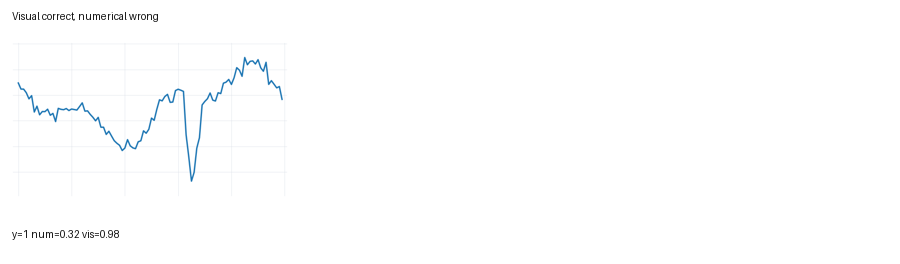

numerical_better_than_visual.png


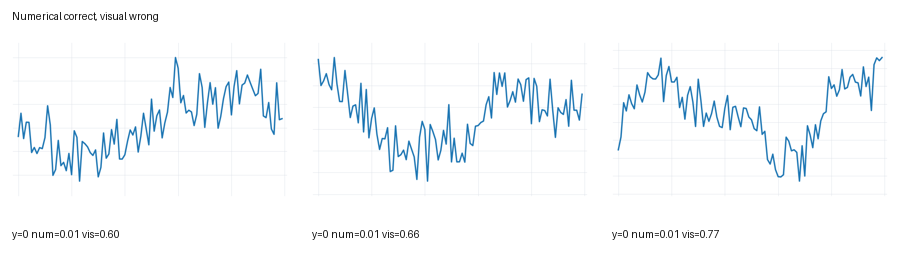

In [9]:
if HAS_TORCH and HAS_CUDA:
    for file_name in ["visual_better_than_numerical.png", "numerical_better_than_visual.png"]:
        image_path = ARTIFACTS_DIR / file_name
        print(image_path.name)
        display(Image.open(image_path).convert("RGB"))